This code makes use of prewritten functions for calculation of fire hazard indices made public by R. Sawtell, which can be found here: https://github.com/buckinha/pyfwi
The package will need to be installed before running the code.

The calculations for historical years are identical, but use ERA5-Land data. In this case, relative humidity must be approximated using the Magnus-Tetens equation.

In [59]:
import sys
import os

# Add package directory to sys.path
sys.path.append(r"pyfwi\build\scripts-3.11")
sys.path.append(r"pyfwi\build\lib")

os.environ['OMP_NUM_THREADS'] = '1'  # Force to a single thread

In [61]:
import pyFWI
import FWI
from FWIFunctions import FFMC, DMC, DC, calcFWI
import __init__

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4


tas = xr.open_dataset('data/2060/tas/tas_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc')
pr = xr.open_dataset('data/daily/pr/pr_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_day_20560101-20601230.nc', engine="netcdf4", mode='r')
hurs = xr.open_dataset("data/2060/hurs/hurs_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc")
sfcWind = xr.open_dataset("data/2060/sfcWind/sfcWind_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc")

tas = tas.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
pr = pr.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
hurs = hurs.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
sfcWind = sfcWind.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)

# Calculations are based on noon values
tas = tas.sel(time = tas.time.dt.hour==12)
hurs = hurs.sel(time = hurs.time.dt.hour == 12)
sfcWind = sfcWind.sel(time = sfcWind.time.dt.hour == 12)

# Extract daily precipitations for 2060
pr = pr.sel(time = pr.time.dt.year == 2060)

The gridded fire hazard indices (FFMC, DMC, DC, FWI) will be stored as an additional property of the DataArray ``tas`` because this DataArray already has the correct latitudes and longitudes built in, easing computation and storage of the indices.

In [65]:
import numpy as np
import xarray as xr

# Ensure tas['data_mask'] is initialized as False for all grid points
tas['data_mask'] = xr.full_like(tas['tas'], False, dtype=bool)

# Function to find the first occurrence of 3 consecutive days with temp ≥ 12°C
# This occurrence signals the start of FWI calculations
def find_start_index(temp_series, threshold=12, window=3):
    """Returns the index of the third consecutive day ≥ threshold, or NaN if not found."""
    temp_series = np.asarray(temp_series)  # Convert to NumPy array
    if temp_series.ndim == 0:  # Ensure input is an array, not a scalar
        return np.nan

    mask = temp_series >= threshold  # Boolean mask

    for i in range(len(mask) - window + 1):
        if mask[i] and mask[i+1] and mask[i+2]:  # Check for 3 consecutive days
            return i+2  # Return the index of the third day
    return np.nan  # Return NaN if no occurrence is found

# Apply function across the lat/lon dimensions
start_indices = xr.apply_ufunc(
    find_start_index,
    tas['tas'] - 273.15,
    input_core_dims=[["time"]],  # Function applies only along 'time'
    vectorize=True,
    dask="parallelized",  # Enables parallel execution if using Dask
    output_dtypes=[np.float64]  # Ensures output is float (NaN handling)
)

# Convert indices to datetime
start_dates = tas['time'][0] + start_indices.astype("timedelta64[D]")

# Define December 1st as the cut-off date for FWI calulcations
december_1st = np.datetime64(f"{tas['time'][0].dt.year.values}-12-01")

# Apply condition: Set True from the start date to December 1st
tas['data_mask'] = (tas['time'] >= start_dates) & (tas['time'] < december_1st)

C:\Users\toete\AppData\Local\Temp\ipykernel_36672\2957161890.py:33: UserWarning: Converting non-nanosecond precision timedelta values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  start_dates = tas['time'][0] + start_indices.astype("timedelta64[D]")


In [67]:
import numpy as np
import xarray as xr

# Initialize FFMC as NaN everywhere
tas['FFMC'] = xr.full_like(tas['tas'], np.nan, dtype=float)

temperature = tas['tas']-273.15
humidity = hurs['hurs']
wind_speed = sfcWind['sfcWind']*3.6
rainfall = pr['pr']*86400
mask = tas['data_mask']

# Process FFMC iteratively for each grid point
for i in range(len(tas.lat)):
    for j in range(len(tas.lon)):
        # Extract time series for this grid cell
        temp_series = temperature[:, i, j].values
        rh_series = humidity[:, i, j].values
        wind_series = wind_speed[:, i, j].values
        rain_series = rainfall[:, i, j].values
        mask_series = mask[:, i, j].values  # Boolean mask

        # Find the first occurrence where mask is True
        if np.any(mask_series):
            first_true_idx = np.argmax(mask_series)  # First index where mask is True
            ffmc_values = np.full_like(temp_series, np.nan)  # Initialize NaNs

            # Set first FFMC value to 85
            ffmc_values[first_true_idx] = 85

            # Compute FFMC iteratively for subsequent masked dates
            for t in range(first_true_idx + 1, len(temp_series)):
                if mask_series[t]:  # Only compute if mask is True
                    prev_ffmc = ffmc_values[t - 1]
                    ffmc_values[t] = FFMC(
                        temp_series[t], rh_series[t], wind_series[t], rain_series[t], prev_ffmc
                    )

            # Store results back into the dataset
            tas['FFMC'][:, i, j] = ffmc_values


In [69]:
# Initialize DMC as NaN everywhere
tas['DMC'] = xr.full_like(tas['tas'], np.nan, dtype=float)

# Get weather variables
temperature = tas['tas']-273.15
humidity = hurs['hurs']
rainfall = pr['pr']*86400
mask = tas['data_mask']

# Extract time and month information
months = tas['time'].dt.month  # Extract month for each timestep

# Process DMC iteratively for each grid point
for i in range(len(tas.lat)):
    for j in range(len(tas.lon)):
        # Extract time series for this grid cell
        temp_series = temperature[:, i, j].values
        rh_series = humidity[:, i, j].values
        rain_series = rainfall[:, i, j].values
        mask_series = mask[:, i, j].values  # Boolean mask
        lat_value = tas.lat[i].values  # Latitude for this grid cell

        # Find the first occurrence where mask is True
        if np.any(mask_series):
            first_true_idx = np.argmax(mask_series)  # First index where mask is True
            dmc_values = np.full_like(temp_series, np.nan)  # Initialize NaNs

            # Set first DMC value
            dmc_values[first_true_idx] = 6

            # Compute DMC iteratively for subsequent masked dates
            for t in range(first_true_idx + 1, len(temp_series)):
                if mask_series[t]:  # Only compute if mask is True
                    prev_dmc = dmc_values[t - 1]
                    month = months[t].values  # Extract current month
                    dmc_values[t] = DMC(
                        temp_series[t], rh_series[t], rain_series[t], prev_dmc, lat_value, month
                    )

            # Store results back into the dataset
            tas['DMC'][:, i, j] = dmc_values


In [71]:
# Initialize DMC as NaN everywhere
tas['DC'] = xr.full_like(tas['tas'], np.nan, dtype=float)

# Get weather variables
temperature = tas['tas']-273.15
rainfall = pr['pr']*86400
mask = tas['data_mask']

# Extract time and month information
months = tas['time'].dt.month  # Extract month for each timestep

# Process DMC iteratively for each grid point
for i in range(len(tas.lat)):
    for j in range(len(tas.lon)):
        # Extract time series for this grid cell
        temp_series = temperature[:, i, j].values
        rain_series = rainfall[:, i, j].values
        mask_series = mask[:, i, j].values  # Boolean mask
        lat_value = tas.lat[i].values  # Latitude for this grid cell

        # Find the first occurrence where mask is True
        if np.any(mask_series):
            first_true_idx = np.argmax(mask_series)  # First index where mask is True
            dc_values = np.full_like(temp_series, np.nan)  # Initialize NaNs

            # Set first DC value
            dc_values[first_true_idx] = 15

            # Compute DMC iteratively for subsequent masked dates
            for t in range(first_true_idx + 1, len(temp_series)):
                if mask_series[t]:  # Only compute if mask is True
                    prev_dc = dc_values[t - 1]
                    month = months[t].values  # Extract current month
                    dc_values[t] = DC(
                        temp_series[t], rain_series[t], prev_dmc, lat_value, month
                    )

            # Store results back into the dataset
            tas['DC'][:, i, j] = dc_values

In [75]:
import numpy as np
import xarray as xr

# Initialize FWI as NaN everywhere
tas['FWI'] = xr.full_like(tas['tas'], np.nan, dtype=float)

temperature = tas['tas']-273.15
humidity = hurs['hurs']
wind_speed = sfcWind['sfcWind']*3.6
rainfall = pr['pr'] * 86400
mask = tas['data_mask']
ffmc = tas['FFMC']
dmc = tas['DMC']
dc = tas['DC'] 

# Extract time and month information
months = tas['time'].dt.month  # Extract month for each timestep

# Process FWI iteratively for each grid point
for i in range(len(tas.lat)):
    for j in range(len(tas.lon)):
        # Extract time series for this grid cell
        temp_series = temperature[:, i, j].values
        rh_series = humidity[:, i, j].values
        wind_series = wind_speed[:, i, j].values
        rain_series = rainfall[:, i, j].values
        mask_series = mask[:, i, j].values  # Boolean mask
        lat_value = tas.lat[i].values  # Latitude for this grid cell
        month_series = months.values  # Month series

        # Find first occurrence where mask is True
        if np.any(mask_series):
            first_true_idx = np.argmax(mask_series)  # First index where mask is True
            fwi_values = np.full_like(temp_series, np.nan)  # Initialize NaNs

            # Initialize first FWI calculation using initial FFMC, DMC, and DC values
            prev_ffmc = 85  # FFMC starting value
            prev_dmc = 6  # DMC starting value
            prev_dc = 15  # Example starting DC value, adjust as needed

            # Compute FWI iteratively for masked days
            for t in range(first_true_idx, len(temp_series)):
                if mask_series[t]:  # Only compute if mask is True
                    month = month_series[t]

                    # Compute FWI using the previous day's values
                    fwi_values[t] = calcFWI(
                        month, temp_series[t], rh_series[t], wind_series[t],
                        rain_series[t], prev_ffmc, prev_dmc, prev_dc, lat_value
                    )

                    # Update previous values for next day's calculation
                    prev_ffmc = ffmc[t, i, j].values
                    prev_dmc = dmc[t, i, j].values
                    prev_dc = dc[t, i, j].values

            # Store results back into the dataset
            tas['FWI'][:, i, j] = fwi_values


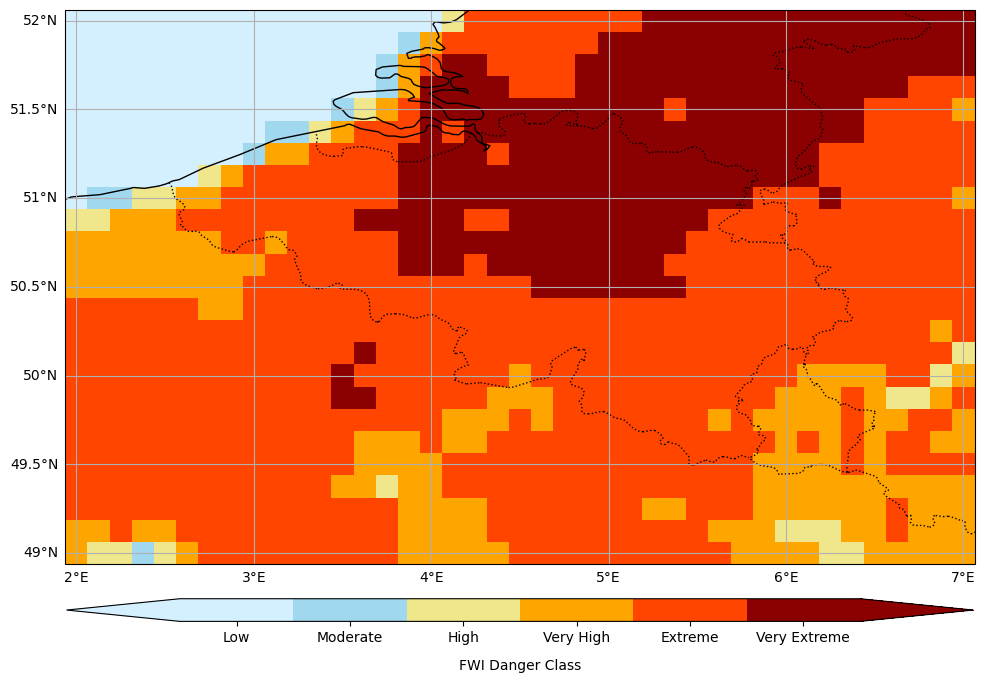

In [79]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import numpy.ma as ma
import matplotlib.colors as mcolors

# Define danger class info
danger_bounds = [0, 11.2, 21.3, 38.0, 50.0, 70.0, np.inf]
danger_names = ["Low", "Moderate", "High", "Very High", "Extreme", "Very Extreme"]
danger_colors = [
    "#d4f0ff",  # Very Low
    "#a0d8ef",  # Low
    "#f0e68c",  # Moderate
    "#ffa500",  # High
    "#ff4500",  # Very High
    "#8b0000"   # Extreme
]
cmap = mcolors.ListedColormap(danger_colors)

# Midpoints of danger intervals for labeling
midpoints = [(danger_bounds[i] + danger_bounds[i + 1]) / 2 for i in range(len(danger_bounds) - 1)]

# Select data
time_index = 166
datestring = str(tas.time[time_index].values)[:10]
fwi = tas.isel(time=time_index)['FWI']
fwi_masked = ma.masked_invalid(fwi)
fwi_classes = np.digitize(fwi_masked, bins=danger_bounds) - 1

# Create plot
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

p = ax.pcolormesh(
    tas.lon, tas.lat, fwi_classes,
    cmap=cmap,
    vmin=0, vmax=len(danger_colors),
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Horizontal colorbar with pointy ends and mid-labels
cbar = plt.colorbar(
    p, ax=ax, orientation='horizontal',
    pad=0.05, aspect=40,
    ticks=np.arange(0.5, len(danger_colors)),  # center of each class box
    extend='both', extendfrac='auto', shrink=0.975
)
cbar.ax.set_xticklabels(danger_names)
cbar.set_label("FWI Danger Class", labelpad=10)
plt.show()